# Lecture 2.4 demo: choosing a chart, and why you plot

ASM 532 - Module 2 - Lecture 2.4

Run top to bottom. It follows the slides:

1. Quiz 2, run for real
2. Why look? The Datasaurus Dozen
3. Choosing a chart: types of data, box or violin, same data with different questions
4. What makes a chart good? Evaluate the quiz chart: is Indiana hotter?
5. How sure can we be? What's really in the Quiz 2 file, and NOAA's Haywood plot

**Data, all in this folder:**

- `kaggle-average_monthly_temperature_by_state_1950-2021.csv`: Justin Wong, [Average Monthly Temperature by US State](https://www.kaggle.com/datasets/justinrwong/average-monthly-temperature-by-us-state), Kaggle (2022), compiled from NOAA NCEI [Climate at a Glance: Statewide Mapping, Average Temperature](https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/mapping/110/tavg/202208/1/value). No license given on Kaggle; the citation to NOAA is real. Trimmed to 1950-2021 to match Quiz 2. **Its "months" are not what they seem: see section 5.**
- `DatasaurusDozen.tsv`: Justin Matejka and George Fitzmaurice. 2017. *Same Stats, Different Graphs.* CHI '17, 1290-1294. https://doi.org/10.1145/3025453.3025912 ([paper, data and code](https://www.autodesk.com/research/publications/same-stats-different-graphs)). The original Datasaurus: Alberto Cairo, 2016.
- `noaa-cag_statewide-*.csv`: NOAA National Centers for Environmental information, [Climate at a Glance](https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/), downloaded 2026-09-16. Each file name records the output and settings that produced it: output (`time-series`, `mapping`, `haywood`), place, parameter (`tavg` = average temperature), time scale, and period.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Quiz 2, run for real

- Same `df` the quiz described: one state, one month, one year per row.
- Check the first and last rows against the quiz handout.
- Everything in sections 1-4 is correct *for this file*. Section 5 asks whether the file is true to its source.

In [2]:
df = pd.read_csv("kaggle-average_monthly_temperature_by_state_1950-2021.csv", index_col=0)
df.head()

,month,year,state,average_temp,monthly_mean_from_1901_to_2000,centroid_lon,centroid_lat
0,1,1950,Alabama,53.8,45.9,-86.828372,32.789832
1,1,1950,Arizona,39.6,41.1,-111.664418,34.293110
2,1,1950,Arkansas,45.6,40.4,-92.439268,34.899745
3,1,1950,California,39.4,42.7,-119.610699,37.246071
4,1,1950,Colorado,25.2,24.5,-105.547825,38.998552


In [3]:
df.tail()

,month,year,state,average_temp,monthly_mean_from_1901_to_2000,centroid_lon,centroid_lat
41467,12,2021,Virginia,45.2,41.1,-78.812254,37.515024
41468,12,2021,Washington,34.7,33.6,-120.446866,47.380969
41469,12,2021,West Virginia,41.8,37.6,-80.613712,38.642599
41470,12,2021,Wisconsin,29.3,24.9,-90.011694,44.638030
41471,12,2021,Wyoming,31.3,24.8,-107.551454,42.999642


**R1, plain English:** keep only the rows where `state` equals `"Indiana"` **and** `year` is 1970 or later. Plot `average_temp` against time, where time combines `year` and `month`.

**R2, Pandas:**

In [4]:
indiana = df[(df["state"] == "Indiana") & (df["year"] >= 1970)]
indiana.shape

(624, 7)

- 52 years × 12 months should give 624 rows, and it does: `(624, 7)`.

**R4, OO style.** The model answer, as written in the solution.

- x is a decimal year: January 1970 is 1970.0, July 1970 is 1970.5.
- So the label "Year" tells the truth about what is plotted.

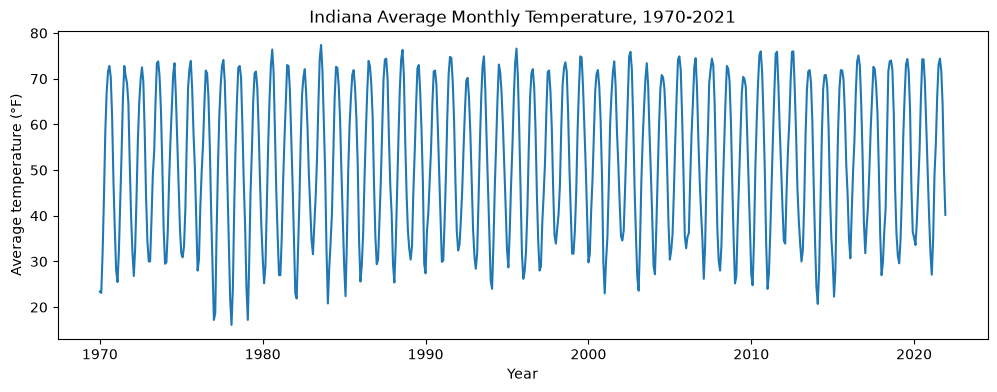

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(indiana["year"] + (indiana["month"] - 1) / 12, indiana["average_temp"])
ax.set_title("Indiana Average Monthly Temperature, 1970-2021")
ax.set_xlabel("Year")
ax.set_ylabel("Average temperature (°F)")
plt.show()

**R4, pyplot style.** Also accepted. Same line, different x-axis.

- **Which label tells the truth?** Only "Year", above.
- `plt.plot()` given one column uses that column's row labels as x.
- `indiana` kept its row labels from `df`, so x runs from about 11,500 to 41,500.
- "Month index (Jan 1970 = 0)" is only true after renumbering the rows. Watch the axis.

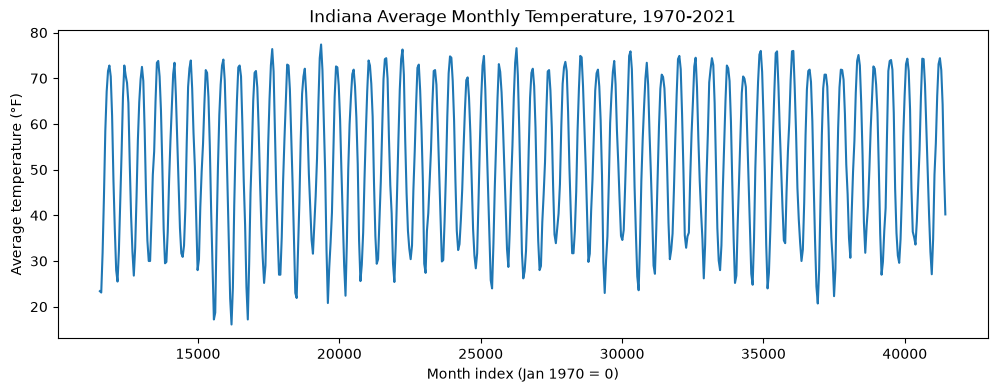

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(indiana["average_temp"])
plt.title("Indiana Average Monthly Temperature, 1970-2021")
plt.xlabel("Month index (Jan 1970 = 0)")
plt.ylabel("Average temperature (°F)")
plt.show()

**Making the pyplot label true:** renumber the rows 0-623 with `.reset_index(drop=True)`.

In [7]:
# Renumber the rows 0-623 before plotting
indiana_numbered = indiana.reset_index(drop=True)
indiana_numbered.index.min(), indiana_numbered.index.max()

(0, 623)

## 2. Why look? The value of exploration: the Datasaurus Dozen

- Thirteen datasets, each with `x` and `y`.
- Describe them first. Plot them second.
- **What do you notice?** The same means, spreads and correlation, to within 0.01, and completely different pictures. Summary statistics can't tell them apart; a plot can.

In [8]:
datasaurus = pd.read_csv("DatasaurusDozen.tsv", sep="\t")
datasaurus["dataset"].unique()

<StringArray>
[      'dino',       'away',    'h_lines',    'v_lines',    'x_shape',
       'star', 'high_lines',       'dots',     'circle',   'bullseye',
   'slant_up', 'slant_down', 'wide_lines']
Length: 13, dtype: str

In [9]:
# The summary statistics, per dataset
datasaurus.groupby("dataset").agg(
    x_mean=("x", "mean"), y_mean=("y", "mean"),
    x_std=("x", "std"), y_std=("y", "std"),
).round(2)

,x_mean,y_mean,x_std,y_std
dataset,,,,
away,54.27,47.83,16.77,26.94
bullseye,54.27,47.83,16.77,26.94
circle,54.27,47.84,16.76,26.93
dino,54.26,47.83,16.77,26.94
dots,54.26,47.84,16.77,26.93
h_lines,54.26,47.83,16.77,26.94
high_lines,54.27,47.84,16.77,26.94
slant_down,54.27,47.84,16.77,26.94
slant_up,54.27,47.83,16.77,26.94


In [10]:
# Correlation between x and y, per dataset
datasaurus.groupby("dataset")[["x", "y"]].corr().xs("x", level=1)["y"].round(2)

dataset
away         -0.06
bullseye     -0.07
circle       -0.07
dino         -0.06
dots         -0.06
h_lines      -0.06
high_lines   -0.07
slant_down   -0.07
slant_up     -0.07
star         -0.06
v_lines      -0.07
wide_lines   -0.07
x_shape      -0.07
Name: y, dtype: float64

- The statistics above are all but identical. Now plot them.

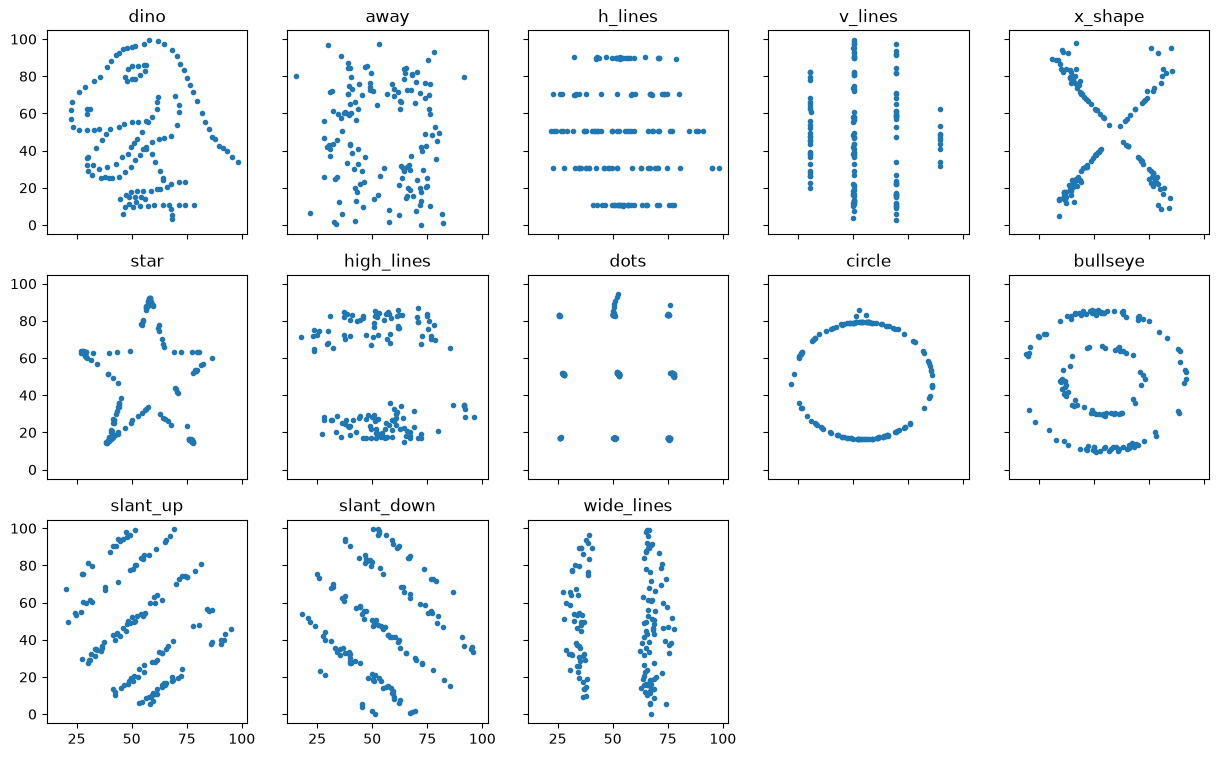

In [11]:
names = datasaurus["dataset"].unique()

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15, 9), sharex=True, sharey=True)
for ax, name in zip(axes.flat, names):
    one = datasaurus[datasaurus["dataset"] == name]
    ax.scatter(one["x"], one["y"], marker=".")
    ax.set_title(name)
for ax in axes.flat[len(names):]:
    ax.axis("off")
plt.show()

**Box or violin, again.** The same thirteen `y` columns.

- The boxes differ, but don't show why. The violins do: `high_lines` and `circle` split into two clusters, `dots` into three, and `h_lines` into five bands. A box can't draw any of that.

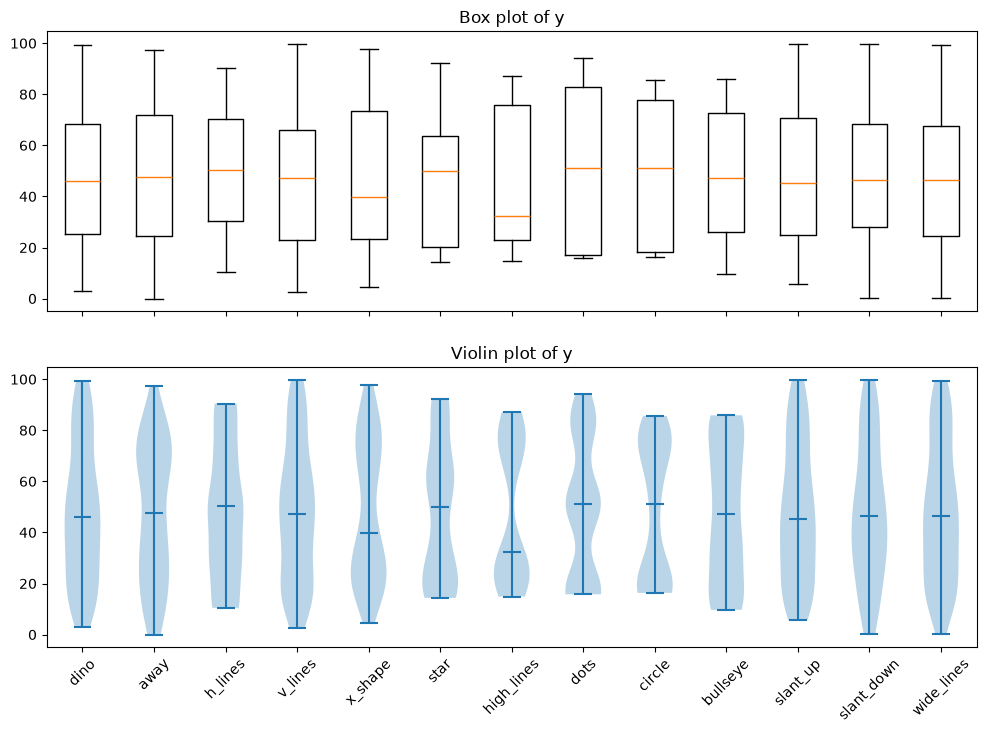

In [12]:
y_by_dataset = [datasaurus[datasaurus["dataset"] == name]["y"] for name in names]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.boxplot(y_by_dataset)
ax1.set_title("Box plot of y")
ax2.violinplot(y_by_dataset, showmedians=True)
ax2.set_title("Violin plot of y")
ax2.set_xticks(range(1, len(names) + 1), labels=names, rotation=45)
plt.show()

- *"The greatest value of a picture is when it forces us to notice what we never expected to see."* John W. Tukey, 1977

## 3. Choosing a chart

**Why choosing a chart matters:** the question picks the chart. The quiz's line chart answers "what happened when?", and hides "is Indiana hotter?" and "how does each month vary?". The data types narrow the choice.

### Back to types of data

- `state`: qualitative, nominal
- `month`: stored as 1-12, but used here as an **ordinal** group
- `year`: quantitative, discrete, interval
- `average_temp`, `monthly_mean_from_1901_to_2000`: quantitative, continuous, interval
- `centroid_lon`, `centroid_lat`: spatial

In [13]:
df.dtypes

month                               int64
year                                int64
state                                 str
average_temp                      float64
monthly_mean_from_1901_to_2000    float64
centroid_lon                      float64
centroid_lat                      float64
dtype: object

In [14]:
df.nunique()

month                              12
year                               72
state                              48
average_temp                      818
monthly_mean_from_1901_to_2000    533
centroid_lon                       48
centroid_lat                       48
dtype: int64

### One number, one category: box or violin?

- `average_temp`: one number
- `month`: one ordinal category
- 52 Januaries, 52 Februaries...: several observations per group
- data-to-viz.com says: **boxplot** or **violin**
- **What does a violin show that a box hides?** The shape. January to March have long, thin lower tails, a few very cold months, which the box plot reduces to a few outlier circles.

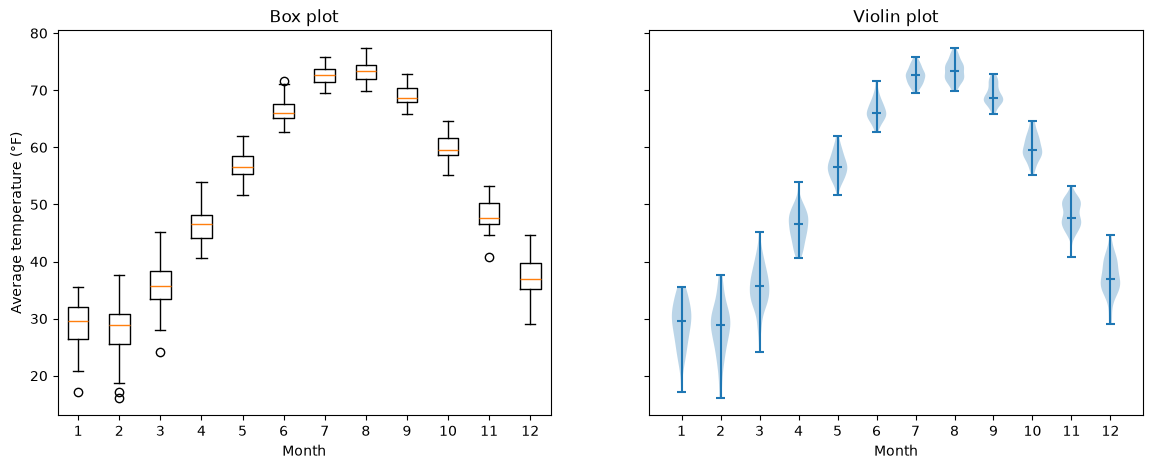

In [15]:
by_month = [indiana[indiana["month"] == m]["average_temp"] for m in range(1, 13)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
ax1.boxplot(by_month)
ax1.set_title("Box plot")
ax1.set_xlabel("Month")
ax1.set_ylabel("Average temperature (°F)")
ax2.violinplot(by_month, showmedians=True)
ax2.set_xticks(range(1, 13))
ax2.set_title("Violin plot")
ax2.set_xlabel("Month")
plt.show()

### Same data, different questions

**How are Indiana's monthly temperatures spread?** One numeric: histogram.

- Not one bell: several humps. Each data point is a month, and months cluster by season, so each season makes its own hump.

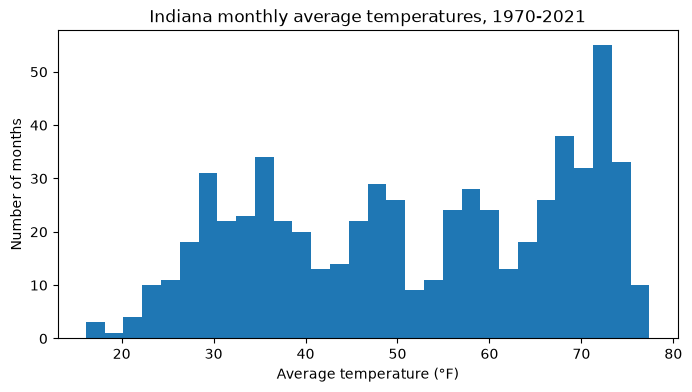

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(indiana["average_temp"], bins=30)
ax.set_title("Indiana monthly average temperatures, 1970-2021")
ax.set_xlabel("Average temperature (°F)")
ax.set_ylabel("Number of months")
plt.show()

**Which states were warmest in 2021?** One numeric, one nominal, one value per group: ranked bar.

- Florida (71.8 °F), Louisiana and Texas. Coolest: Wyoming (43.5 °F), North Dakota and Montana.
- Indiana sits exactly mid-table: 24th of 48.

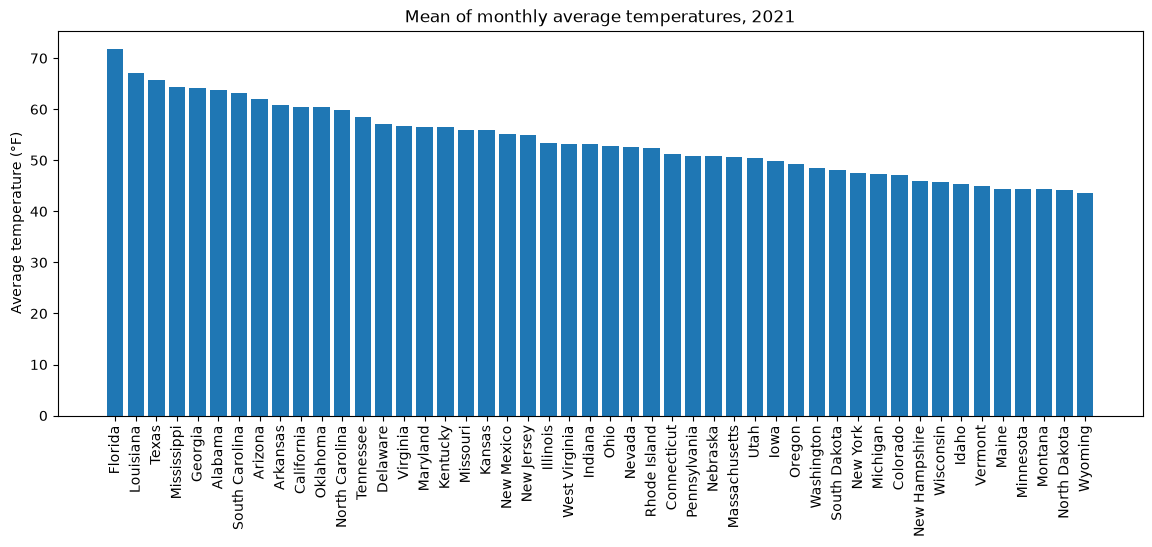

In [17]:
by_state_2021 = df[df["year"] == 2021].groupby("state")["average_temp"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(by_state_2021.index, by_state_2021.values)
ax.set_title("Mean of monthly average temperatures, 2021")
ax.set_ylabel("Average temperature (°F)")
ax.tick_params(axis="x", labelrotation=90)
plt.show()

**Where are the warmest states?** One numeric, spatial: bubble map.

- Mostly the southern states: in 2021, temperature follows latitude (correlation -0.95), not longitude (0.10).
- No map library here: each state is one point at its centroid, coloured by temperature.
- Real maps: Geopandas & Geoplot, from the Python Plotting Libraries slide.

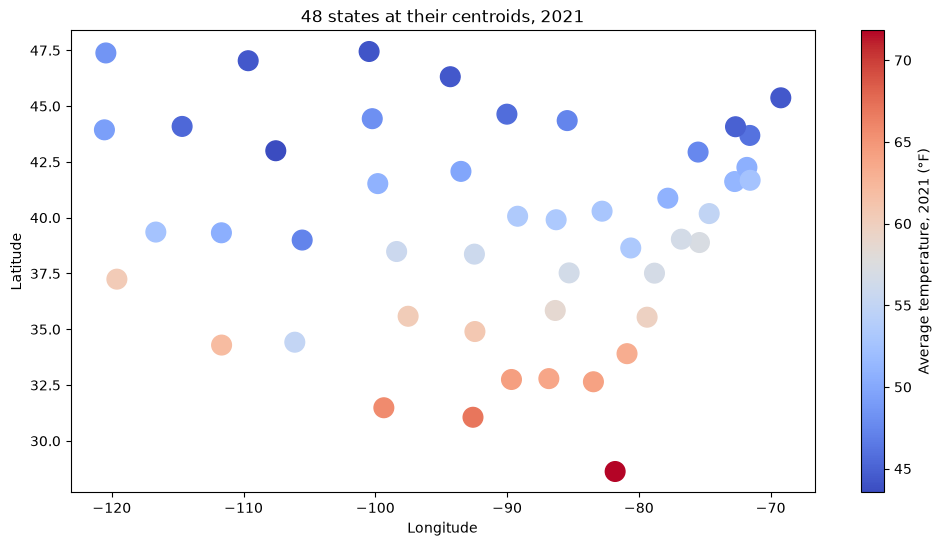

In [18]:
states_2021 = df[df["year"] == 2021].groupby("state")[["centroid_lon", "centroid_lat", "average_temp"]].mean()

fig, ax = plt.subplots(figsize=(12, 6))
points = ax.scatter(states_2021["centroid_lon"], states_2021["centroid_lat"],
                    c=states_2021["average_temp"], s=200, cmap="coolwarm")
fig.colorbar(points, label="Average temperature, 2021 (°F)")
ax.set_title("48 states at their centroids, 2021")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

**How does each month compare to its 1901-2000 mean?** Two numeric: scatter.

- Points above the black line were warmer than normal for that month: 56% of them.
- Expect vertical stripes: each calendar month has one normal, so each month is a stripe.
- The stripes sit in near-pairs because spring and fall months have similar normals: March and December, April and November, May and October, June and September, July and August.

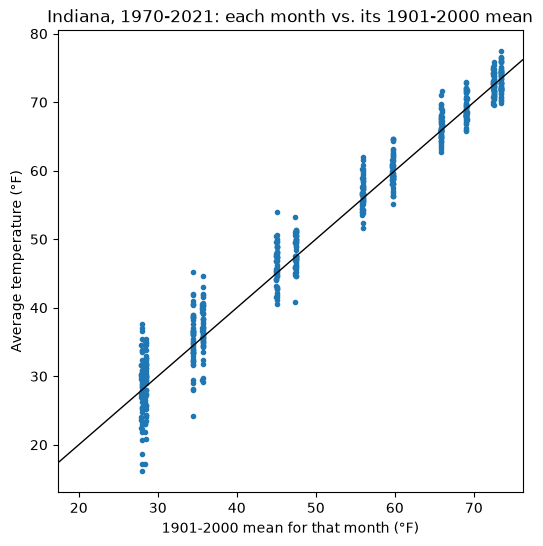

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(indiana["monthly_mean_from_1901_to_2000"], indiana["average_temp"], marker=".")
ax.axline((20, 20), slope=1, color="black", linewidth=1)   # points above this line were warmer than normal
ax.set_title("Indiana, 1970-2021: each month vs. its 1901-2000 mean")
ax.set_xlabel("1901-2000 mean for that month (°F)")
ax.set_ylabel("Average temperature (°F)")
plt.show()

**Keep an eye on those stripes.** One stripe per calendar month should mean one 1901-2000 normal per month. Section 4 checks that column directly, and section 5 goes to the source.

## 4. What makes a chart good? Evaluate the quiz chart: what does it let you say?

- 52 years of seasons: the line is mostly summer and winter.
- **Is Indiana hotter?** Not visible in the quiz chart. The seasons swamp it.
- The data already has `monthly_mean_from_1901_to_2000`, the 20th-century average for that month.
- Subtract it: how far above or below normal was each month? The rolling mean smooths out single odd months.

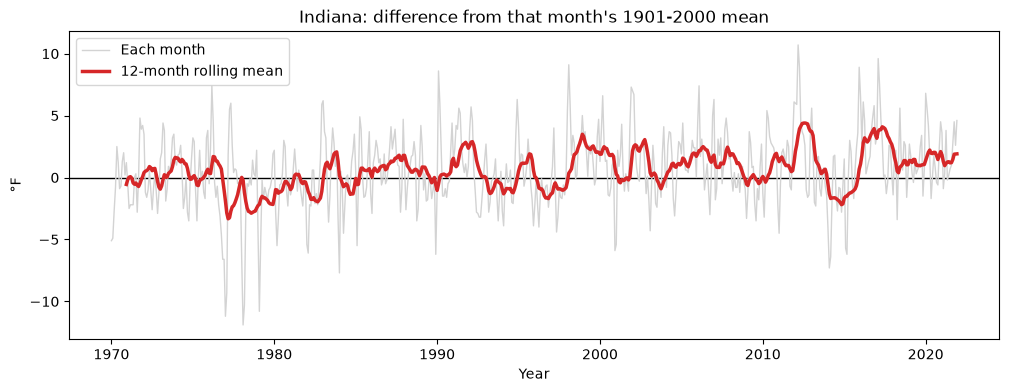

In [20]:
difference = indiana["average_temp"] - indiana["monthly_mean_from_1901_to_2000"]
time = indiana["year"] + (indiana["month"] - 1) / 12

fig, ax = plt.subplots(figsize=(12, 4))
ax.axhline(0, color="black", linewidth=1)
ax.plot(time, difference, color="lightgray", linewidth=1, label="Each month")
ax.plot(time, difference.rolling(12).mean(), color="tab:red", linewidth=2.5, label="12-month rolling mean")
ax.set_title("Indiana: difference from that month's 1901-2000 mean")
ax.set_xlabel("Year")
ax.set_ylabel("°F")
ax.legend(loc="upper left")
plt.show()

- **Yes, Indiana is hotter.** Months averaged 0.5 °F *below* their 1901-2000 mean in the 1970s, and 1.35 °F *above* it in the 2010s.
- Averaging by decade makes that one number per decade.

In [21]:
# Average difference per decade
decade = (indiana["year"] // 10) * 10
difference.groupby(decade).mean().round(2)

year
1970   -0.51
1980    0.07
1990    0.70
2000    1.00
2010    1.35
2020    2.00
dtype: float64

**Where did this data come from, and how sure can we be?**

- A 2022 Kaggle upload of NOAA NCEI Climate at a Glance data. No license given on Kaggle; the citation to NOAA is real.
- Not yet checked against NOAA: do the values match? How was the 1901-2000 mean computed? Has NOAA revised anything since?
- One warning sign already: the "1901-2000 mean" for a month is not one number. It flips by 0.1 °F from year to year (January: 28.5, 28.4, 28.5...), in every state. First guess: rounding in how the file was built. Check it in the next cell; section 5 shows it's more than rounding.
- Until those are checked, "Indiana is hotter" rests on a copy of the data, not the source.

In [22]:
# A fixed 1901-2000 mean should give one value per month
indiana.groupby("month")["monthly_mean_from_1901_to_2000"].unique()

month
1     [28.5, 28.4]
2     [28.0, 27.9]
3     [34.5, 34.4]
4     [45.0, 45.1]
5     [56.0, 55.9]
6     [65.9, 66.0]
7     [72.5, 72.4]
8     [73.5, 73.4]
9     [69.1, 69.0]
10    [59.8, 59.7]
11    [47.4, 47.5]
12    [35.7, 35.6]
Name: monthly_mean_from_1901_to_2000, dtype: object

## 5. How sure can we be? What's really in this file

- **Where it came from:** Kaggle. It cites NOAA's Climate at a Glance *Statewide Mapping* page, which is a map of one month across states, not 72 years of months.
- **What NOAA's Time Series output asks for:** a *Time Scale* (1-month, 2-month, 3-month… year-to-date). Nothing in the Kaggle file records which one was used.
- **The test:** compare the Kaggle file's Indiana "December" with NOAA's own Indiana series at two time scales, both downloaded from NOAA and named with their settings.
- **Answer:** the Kaggle "December" matches NOAA's **2-month (November-December)** series within 0.1 °F in every year, and is far from true December. Every other month matches its 2-month series too (checked for Indiana, Alabama and Wyoming).

In [23]:
kaggle_dec = df[(df["state"] == "Indiana") & (df["month"] == 12)].set_index("year")["average_temp"]

one_month = pd.read_csv("noaa-cag_statewide-time-series_indiana_tavg_1-month_dec_1950-2021.csv", comment="#")
two_month = pd.read_csv("noaa-cag_statewide-time-series_indiana_tavg_2-month_nov-dec_1950-2021.csv", comment="#")
one_month["year"] = one_month["Date"] // 100
two_month["year"] = two_month["Date"] // 100

compare = pd.DataFrame({
    "kaggle_december": kaggle_dec,
    "noaa_1_month_dec": one_month.set_index("year")["Value"],
    "noaa_2_month_nov_dec": two_month.set_index("year")["Value"],
})
compare.head()

,kaggle_december,noaa_1_month_dec,noaa_2_month_nov_dec
year,,,
1950,29.2,22.9,29.2
1951,31.7,29.5,31.7
1952,38.0,33.6,38.0
1953,37.2,32.0,37.2
1954,36.2,31.3,36.2


In [24]:
# Largest gap between the Kaggle file and each NOAA series, over 1950-2021
(compare[["noaa_1_month_dec", "noaa_2_month_nov_dec"]].sub(compare["kaggle_december"], axis=0)).abs().max().round(2)

noaa_1_month_dec        12.5
noaa_2_month_nov_dec     0.1
dtype: float64

- The Kaggle line should sit on whichever NOAA line it really is. It sits on the 2-month line.

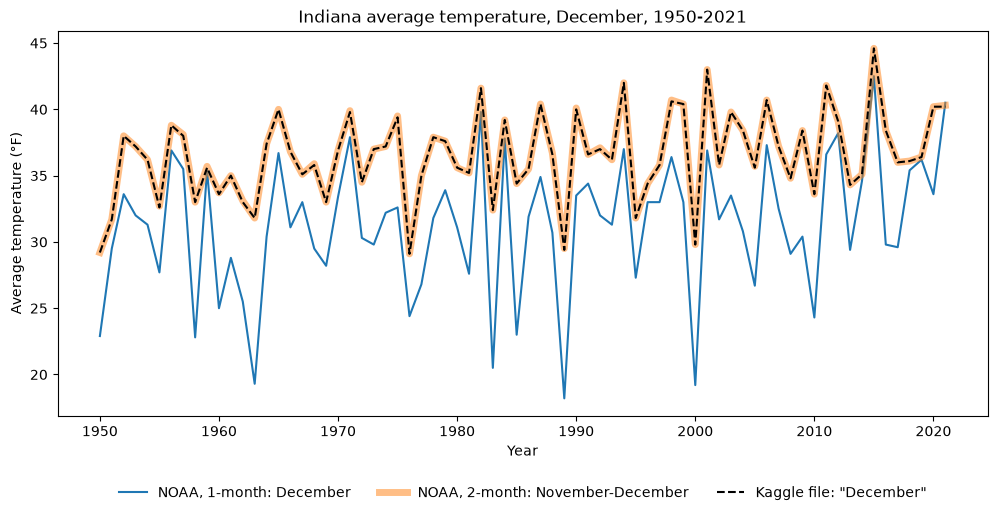

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(compare.index, compare["noaa_1_month_dec"], color="tab:blue", label="NOAA, 1-month: December")
ax.plot(compare.index, compare["noaa_2_month_nov_dec"], color="tab:orange", linewidth=5, alpha=0.5, label="NOAA, 2-month: November-December")
ax.plot(compare.index, compare["kaggle_december"], color="black", linestyle="--", label='Kaggle file: "December"')
ax.set_title("Indiana average temperature, December, 1950-2021")
ax.set_xlabel("Year")
ax.set_ylabel("Average temperature (°F)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.show()

**The normals don't match either.** NOAA's December 2022 statewide map gives each state's December 1901-2000 mean. Kaggle's December "1901-2000 mean" for Indiana is 35.6-35.7 °F; NOAA's is 30.3 °F. Kaggle's is the 2-month normal.

In [26]:
noaa_dec_2022 = pd.read_csv("noaa-cag_statewide-mapping_contiguous-us_tavg_1-month_2022-12.csv", comment="#")
noaa_dec_2022[noaa_dec_2022["Name"] == "Indiana"]

,ID,Name,Value,Anomaly (1901-2000 base period),Rank,1901-2000 Mean
11,12,Indiana,31.7,1.4,70,30.3


In [27]:
df[(df["state"] == "Indiana") & (df["month"] == 12)]["monthly_mean_from_1901_to_2000"].unique()

array([35.7, 35.6])

### What this changes

- **Still true:** Indiana is warming. Winter varies more than summer. The histogram's humps are seasons. 2021's warmest states, and the latitude pattern.
- **Not true:** "monthly". Each month is that month plus the one before, so "January" includes December, and the "1901-2000 means" are 2-month normals.
- **Explained:** the 0.1 °F wobble in the normals, probably rounding when the file was built.
- The charts in sections 1-4 were right for the file. The file wasn't what it said it was.

### The right tool for the job: NOAA's Haywood plot

- NOAA's own answer to "is Indiana hotter?": every year's running year-to-date average, January to December, from 1895.
- Settings: Statewide Haywood, Indiana, Average Temperature, January-December. They're in the file name.
- **Answer:** the average over 1895-2025 ends the year at 51.6 °F. The five warmest years are 2024, 2012, 1998, 1921 and 2023; three of them are since 2012. The five coldest are 1917, 1904, 1912, 1924 and 1978.
- 2026 is shown through August only: it ranks 14th of 132 years for January-August so far.

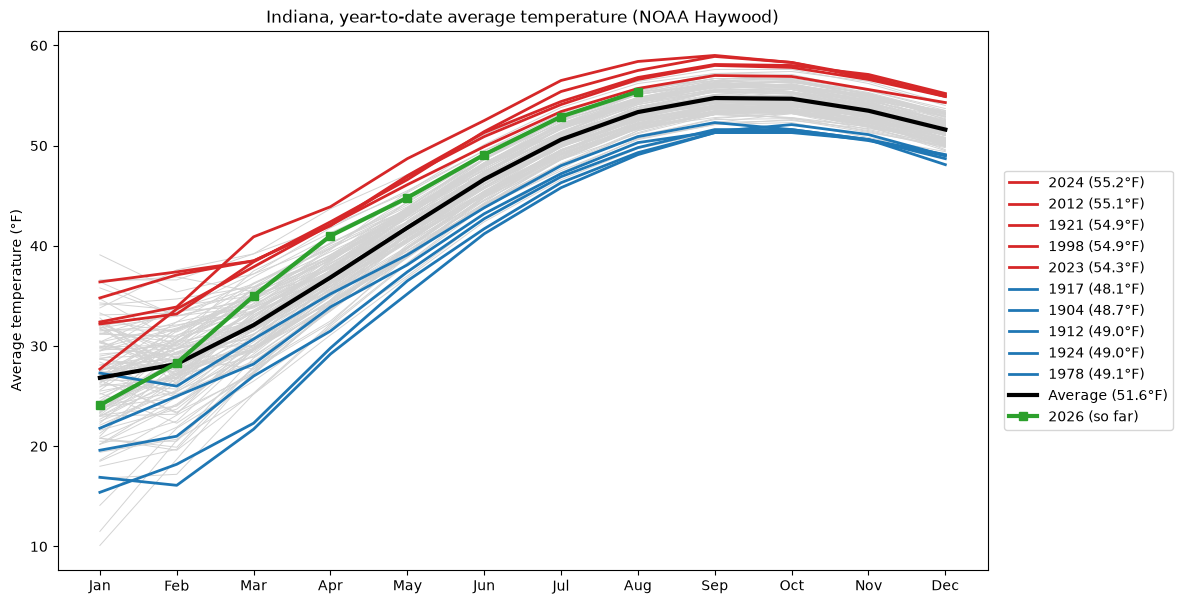

In [28]:
haywood = pd.read_csv("noaa-cag_statewide-haywood_indiana_tavg_jan-dec_1895-2026.csv", comment="#")

# One column per year, one row per month
by_year = haywood.pivot(index="Month", columns="Year", values="Value")
complete = by_year.loc[:, by_year.loc[12].notna()]          # years with all 12 months
current = by_year.columns.max()                              # the year in progress

year_end = complete.loc[12].sort_values()
warmest = year_end.index[-5:][::-1]
coldest = year_end.index[:5]
average = complete.mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(complete.index, complete, color="lightgray", linewidth=0.7)
for year in warmest:
    ax.plot(by_year.index, by_year[year], color="tab:red", linewidth=2, label=f"{year} ({year_end[year]:.1f}°F)")
for year in coldest:
    ax.plot(by_year.index, by_year[year], color="tab:blue", linewidth=2, label=f"{year} ({year_end[year]:.1f}°F)")
ax.plot(average.index, average, color="black", linewidth=3, label=f"Average ({average[12]:.1f}°F)")
ax.plot(by_year.index, by_year[current], color="tab:green", linewidth=3, marker="s", label=f"{current} (so far)")
ax.set_xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_title("Indiana, year-to-date average temperature (NOAA Haywood)")
ax.set_ylabel("Average temperature (°F)")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.show()

### The metadata lesson

- A citation that names the page and the date is not enough to reproduce the data. NOAA's own "Citing This Page" template records neither the time scale nor the month.
- When you download data, keep the **settings** with it: output, place, parameter, time scale, period, date. Put them in the file name, a README, or both.
- When you use someone else's copy, test it against the source before you trust it.